# Step 7: Proportional Hazards Assumption Testing
## Schoenfeld Residual Diagnostics

**Why this matters:** Cox PH models assume that hazard ratios are constant over time. If this assumption is violated, the HR we reported in Step 6 may be misleading. Reviewers WILL check this.

### Tests
1. **Global test:** Does the overall model satisfy PH? (p > 0.05 = good)
2. **Per-variable test:** Which specific covariates violate PH?
3. **Schoenfeld residual plots:** Visual check for time-varying effects
4. **Log-log survival plots:** Parallel lines = PH satisfied

If violations are found, we note them as limitations or fit time-interaction models.

In [1]:
# ============================================================
# STEP 7.1 — Setup and refit the full model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})
COLORS = ['#4338CA', '#E11D48', '#10B981', '#F59E0B', '#3B82F6', '#8B5CF6']
FIG_DIR = Path('figures')

df = pd.read_csv('data/analytic_cohort.csv')
cs = df[df['cancer'] == 1].copy()
cs['T'] = cs['follow_up_yrs'].clip(upper=20)
cs['E'] = cs['dead']
cs['race_black'] = (cs['race_ethnicity'] == 'Non-Hispanic Black').astype(int)
cs['race_mexican'] = (cs['race_ethnicity'] == 'Mexican American').astype(int)
cs['race_hispanic'] = (cs['race_ethnicity'] == 'Other Hispanic').astype(int)
cs['race_other'] = (cs['race_ethnicity'] == 'Other/Multi').astype(int)
cs['smoke_former'] = (cs['smoking'] == 'Former').astype(int)
cs['smoke_current'] = (cs['smoking'] == 'Current').astype(int)

covariates = ['diabetes', 'hypertension', 'obese', 'age', 'female',
              'race_black', 'race_mexican', 'race_hispanic', 'race_other',
              'smoke_former', 'smoke_current']

cs_complete = cs.dropna(subset=covariates + ['T', 'E']).copy()

# Fit the full model
cph = CoxPHFitter()
cph.fit(cs_complete[covariates + ['T', 'E']], duration_col='T', event_col='E')
print(f'Model fit: N={len(cs_complete):,}, Events={cs_complete["E"].sum():,}')
print(f'Concordance: {cph.concordance_index_:.3f}')

Model fit: N=4,715, Events=1,676
Concordance: 0.733


In [2]:
# ============================================================
# STEP 7.2 — Formal PH test (Schoenfeld residuals)
# ============================================================
# Uses lifelines' built-in proportional_hazard_test which computes
# the correlation between scaled Schoenfeld residuals and time.

ph_test = proportional_hazard_test(cph, cs_complete[covariates + ['T', 'E']], time_transform='rank')

print('=== PROPORTIONAL HAZARDS ASSUMPTION TEST ===')
print('H0: Hazard ratio is constant over time (PH holds)')
print('If p < 0.05, PH assumption is violated for that variable.')
print()
print(f'{"Variable":<25} {"Test Statistic":<18} {"P-value":<12} {"Verdict"}')
print('-' * 70)

violations = []
for var in covariates:
    row = ph_test.summary.loc[var]
    ts = row['test_statistic']
    p = row['p']
    verdict = 'VIOLATED' if p < 0.05 else 'OK'
    if p < 0.05:
        violations.append(var)
    p_str = f'{p:.4f}' if p >= 0.001 else '<0.001'
    print(f'{var:<25} {ts:<18.2f} {p_str:<12} {verdict}')

print()
if violations:
    print(f'Variables violating PH: {violations}')
    print('These variables may have time-varying effects.')
    print('We will address this in sensitivity analyses.')
else:
    print('All variables satisfy the PH assumption.')

=== PROPORTIONAL HAZARDS ASSUMPTION TEST ===
H0: Hazard ratio is constant over time (PH holds)
If p < 0.05, PH assumption is violated for that variable.

Variable                  Test Statistic     P-value      Verdict
----------------------------------------------------------------------
diabetes                  0.10               0.7572       OK
hypertension              1.66               0.1978       OK
obese                     5.47               0.0193       VIOLATED
age                       50.25              <0.001       VIOLATED
female                    0.30               0.5832       OK
race_black                3.27               0.0707       OK
race_mexican              0.14               0.7048       OK
race_hispanic             1.06               0.3040       OK
race_other                1.36               0.2437       OK
smoke_former              2.14               0.1439       OK
smoke_current             0.05               0.8241       OK

Variables violating PH: [

The ``p_value_threshold`` is set at 1. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 4715 total observations, 3039 right-censored observations>
         test_name = proportional_hazard_test

---
                    test_statistic      p  -log2(p)
age           km             43.68 <0.005     34.59
              rank           50.25 <0.005     39.43
diabetes      km              0.04   0.84      0.26
              rank            0.10   0.76      0.40
female        km              0.34   0.56      0.84
              rank            0.30   0.58      0.78
hypertension  km              1.21   0.27      1.88
              rank            1.66   0.20      2.34
obese         km              4.76   0.03      5.10
              rank            5.47   0.02      5.69
race_black    km              2.13   0.14      2.79
              rank            3.27   0.07      3.82
race_hispanic km              0.79   0.37      1.42
              rank            1.06   0.30      1.72
race_mexican  km              0.31   0.58      0.79
              rank            0.14   0.70      0.50
race_other    km              0.88   0.35      1.52
              rank            1.36   0.24      2.04
smoke_current km              0.03   0.87      0.20
              rank            0.05   0.82      0.28
smoke_former  km              1.88   0.17      2.55
              rank            2.14   0.14      2.80



1. Variable 'diabetes' failed the non-proportional test: p-value is 0.7572.

   Advice: with so few unique values (only 2), you can include `strata=['diabetes', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'hypertension' failed the non-proportional test: p-value is 0.1978.

   Advice: with so few unique values (only 2), you can include `strata=['hypertension', ...]` in the
call in `.fit`. See documentation in link [E] below.

3. Variable 'obese' failed the non-proportional test: p-value is 0.0193.

   Advice: with so few unique values (only 2), you can include `strata=['obese', ...]` in the call
in `.fit`. See documentation in link [E] below.

4. Variable 'age' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] belo

The ``p_value_threshold`` is set at 1. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 4715 total observations, 3039 right-censored observations>
         test_name = proportional_hazard_test

---
                    test_statistic      p  -log2(p)
age           km             43.68 <0.005     34.59
              rank           50.25 <0.005     39.43
diabetes      km              0.04   0.84      0.26
              rank            0.10   0.76      0.40
female        km              0.34   0.56      0.84
              rank            0.30   0.58      0.78
hypertension  km              1.21   0.27      1.88
              rank            1.66   0.20      2.34
obese         km              4.76   0.03      5.10
              rank            5.47   0.02      5.69
race_black    km              2.13   0.14      2.79
              rank            3.27   0.07      3.82
race_hispanic km              0.79   0.37      1.42
              rank            1.06   0.30      1.72
race_mexican  km              0.31   0.58      0.79
              rank            0.14   0.70      0.50
race_other    km              0.88   0.35      1.52
              rank            1.36   0.24      2.04
smoke_current km              0.03   0.87      0.20
              rank            0.05   0.82      0.28
smoke_former  km              1.88   0.17      2.55
              rank            2.14   0.14      2.80

...

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 4715 total observations, 3039 right-censored observations>
         test_name = proportional_hazard_test

---
                    test_statistic      p  -log2(p)
age           km             43.68 <0.005     34.59
              rank           50.25 <0.005     39.43
diabetes      km              0.04   0.84      0.26
              rank            0.10   0.76      0.40
female        km              0.34   0.56      0.84
              rank            0.30   0.58      0.78
hypertension  km              1.21   0.27      1.88
              rank            1.66   0.20      2.34
obese         km              4.76   0.03      5.10
              rank            5.47   0.02      5.69
race_black    km              2.13   0.14      2.79
              rank            3.27   0.07      3.82
race_hispanic km              0.79   0.37      1.42
              rank            1.06   0.30      1.72
race_mexican  km              0.31   0.58      0.79
              rank            0.14   0.70      0.50
race_other    km              0.88   0.35      1.52
              rank            1.36   0.24      2.04
smoke_current km              0.03   0.87      0.20
              rank            0.05   0.82      0.28
smoke_former  km              1.88   0.17      2.55
              rank            2.14   0.14      2.80



1. Variable 'diabetes' failed the non-proportional test: p-value is 0.7572.

   Advice: with so few unique values (only 2), you can include `strata=['diabetes', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'hypertension' failed the non-proportional test: p-value is 0.1978.

   Advice: with so few unique values (only 2), you can include `strata=['hypertension', ...]` in the
call in `.fit`. See documentation in link [E] below.

3. Variable 'obese' failed the non-proportional test: p-value is 0.0193.

   Advice: with so few unique values (only 2), you can include `strata=['obese', ...]` in the call
in `.fit`. See documentation in link [E] below.

4. Variable 'age' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] belo

The ``p_value_threshold`` is set at 1. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 4715 total observations, 3039 right-censored observations>
         test_name = proportional_hazard_test

---
                    test_statistic      p  -log2(p)
age           km             43.68 <0.005     34.59
              rank           50.25 <0.005     39.43
diabetes      km              0.04   0.84      0.26
              rank            0.10   0.76      0.40
female        km              0.34   0.56      0.84
              rank            0.30   0.58      0.78
hypertension  km              1.21   0.27      1.88
              rank            1.66   0.20      2.34
obese         km              4.76   0.03      5.10
              rank            5.47   0.02      5.69
race_black    km              2.13   0.14      2.79
              rank            3.27   0.07      3.82
race_hispanic km              0.79   0.37      1.42
              rank            1.06   0.30      1.72
race_mexican  km              0.31   0.58      0.79
              rank            0.14   0.70      0.50
race_other    km              0.88   0.35      1.52
              rank            1.36   0.24      2.04
smoke_current km              0.03   0.87      0.20
              rank            0.05   0.82      0.28
smoke_former  km              1.88   0.17      2.55
              rank            2.14   0.14      2.80



1. Variable 'diabetes' failed the non-proportional test: p-value is 0.7572.

   Advice: with so few unique values (only 2), you can include `strata=['diabetes', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'hypertension' failed the non-proportional test: p-value is 0.1978.

   Advice: with so few unique values (only 2), you can include `strata=['hypertension', ...]` in the
call in `.fit`. See documentation in link [E] below.

3. Variable 'obese' failed the non-proportional test: p-value is 0.0193.

   Advice: with so few unique values (only 2), you can include `strata=['obese', ...]` in the call
in `.fit`. See documentation in link [E] below.

4. Variable 'age' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] belo

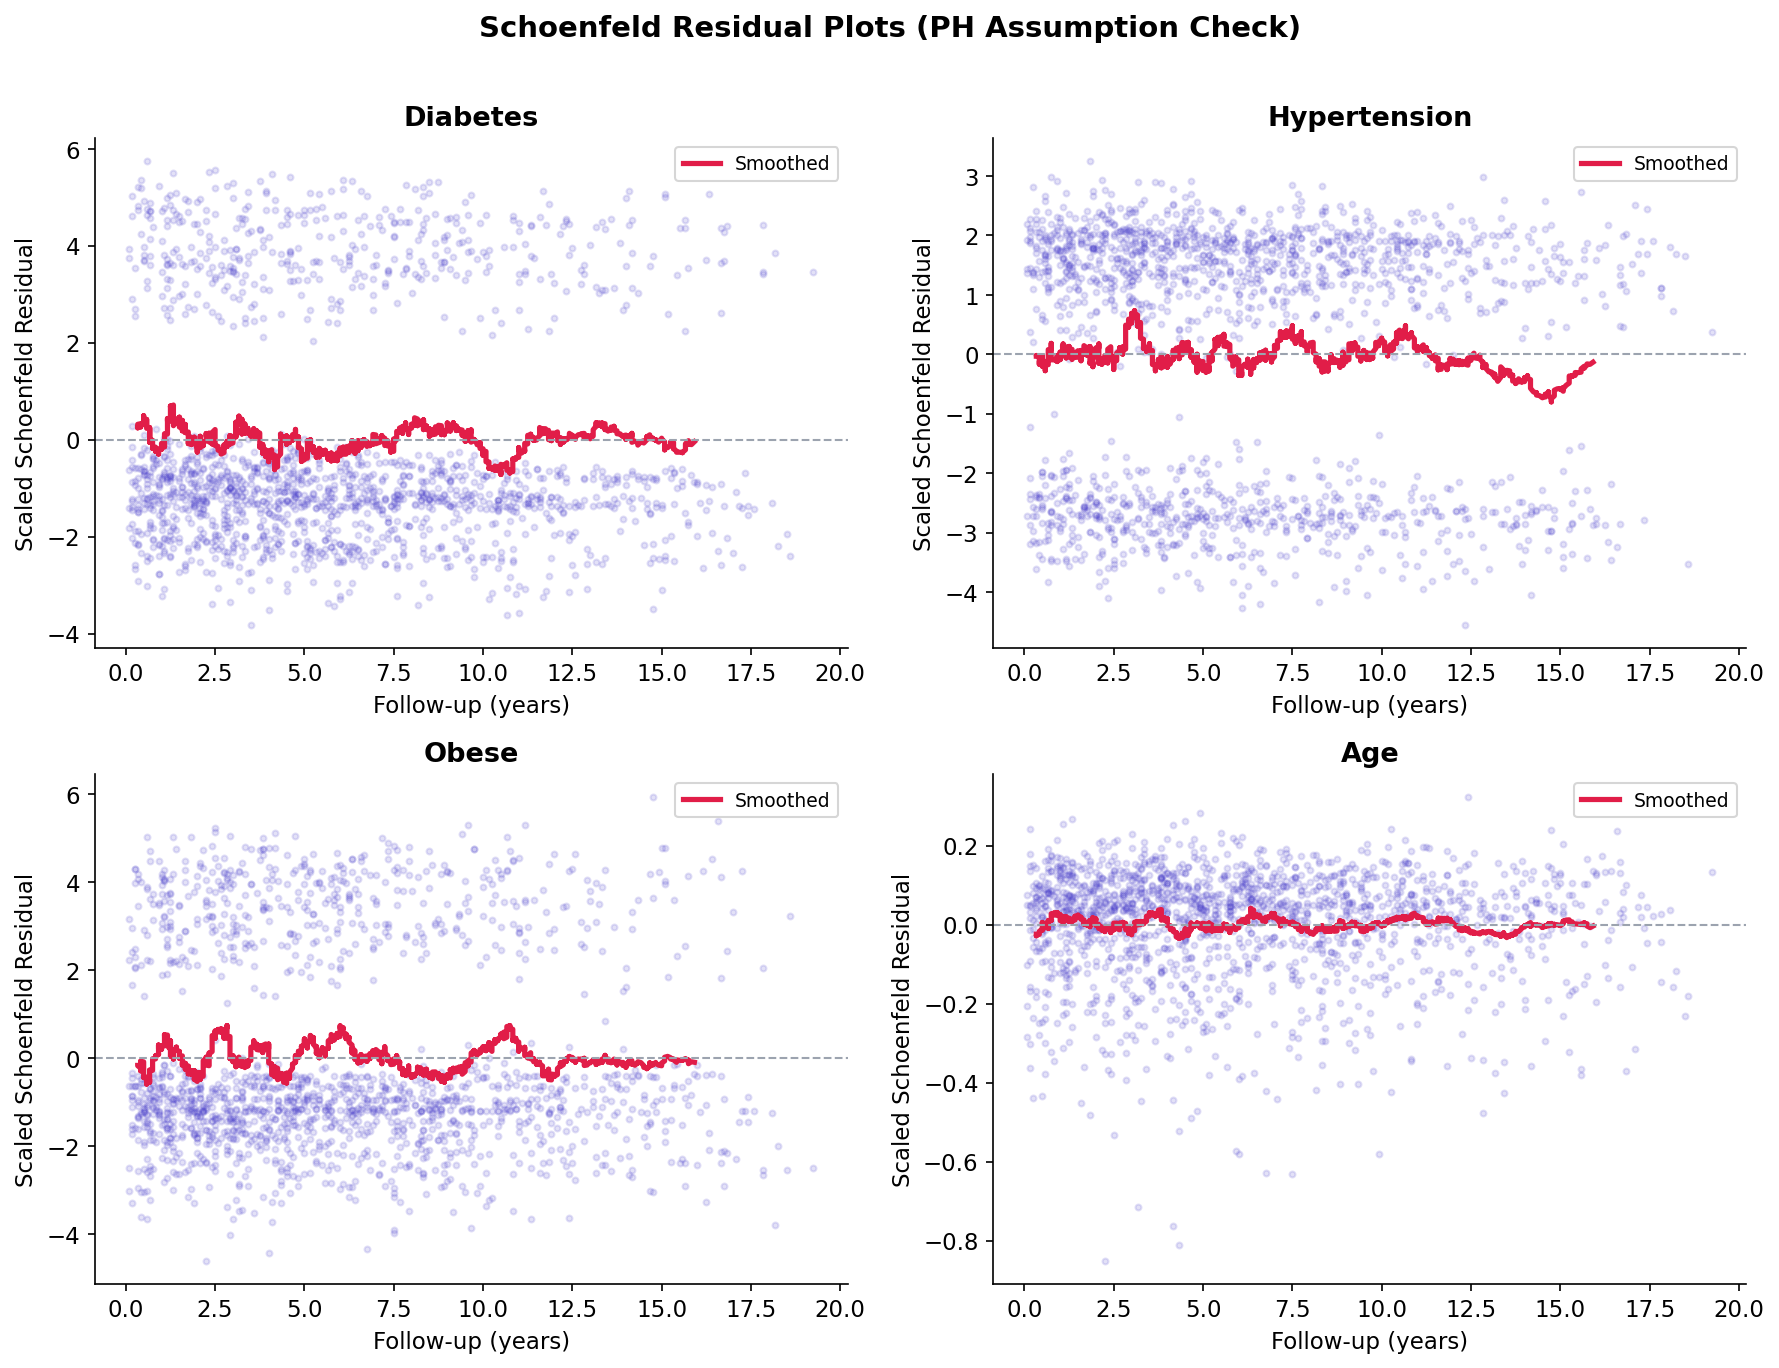

Saved: figures/schoenfeld_residuals.png

Interpretation: Flat LOWESS line = PH holds. Sloped line = time-varying effect.


In [3]:
# ============================================================
# STEP 7.3 — Schoenfeld residual plots for key exposures
# ============================================================
# Visual assessment: if the LOWESS smoothed line is flat (horizontal),
# the PH assumption holds for that variable.

key_vars = ['diabetes', 'hypertension', 'obese', 'age']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for idx, var in enumerate(key_vars):
    ax = axes[idx // 2, idx % 2]
    cph.check_assumptions(cs_complete[covariates + ['T', 'E']], 
                          p_value_threshold=1.0,  # don't filter
                          show_plots=False)  # we'll plot manually
    
    # Get Schoenfeld residuals
    resids = cph.compute_residuals(cs_complete[covariates + ['T', 'E']], kind='scaled_schoenfeld')
    
    # Sort by time
    r = resids[[var]].copy()
    r['time'] = cs_complete.loc[cs_complete['E'] == 1, 'T'].values[:len(r)]
    r = r.sort_values('time')
    
    ax.scatter(r['time'], r[var], alpha=0.15, s=8, color=COLORS[0])
    
    # LOWESS smoothing
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        smooth = lowess(r[var].values, r['time'].values, frac=0.3)
        ax.plot(smooth[:, 0], smooth[:, 1], color=COLORS[1], linewidth=2.5, label='LOWESS')
    except ImportError:
        # Rolling mean fallback
        window = max(len(r) // 20, 10)
        rolling = r.set_index('time')[var].rolling(window, center=True).mean()
        ax.plot(rolling.index, rolling.values, color=COLORS[1], linewidth=2.5, label='Smoothed')
    
    ax.axhline(0, color='#9CA3AF', linestyle='--', linewidth=1)
    ax.set_xlabel('Follow-up (years)')
    ax.set_ylabel('Scaled Schoenfeld Residual')
    ax.set_title(f'{var.capitalize()}')
    ax.legend(fontsize=9)

plt.suptitle('Schoenfeld Residual Plots (PH Assumption Check)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'schoenfeld_residuals.png', bbox_inches='tight')
plt.show()
print('Saved: figures/schoenfeld_residuals.png')
print('\nInterpretation: Flat LOWESS line = PH holds. Sloped line = time-varying effect.')

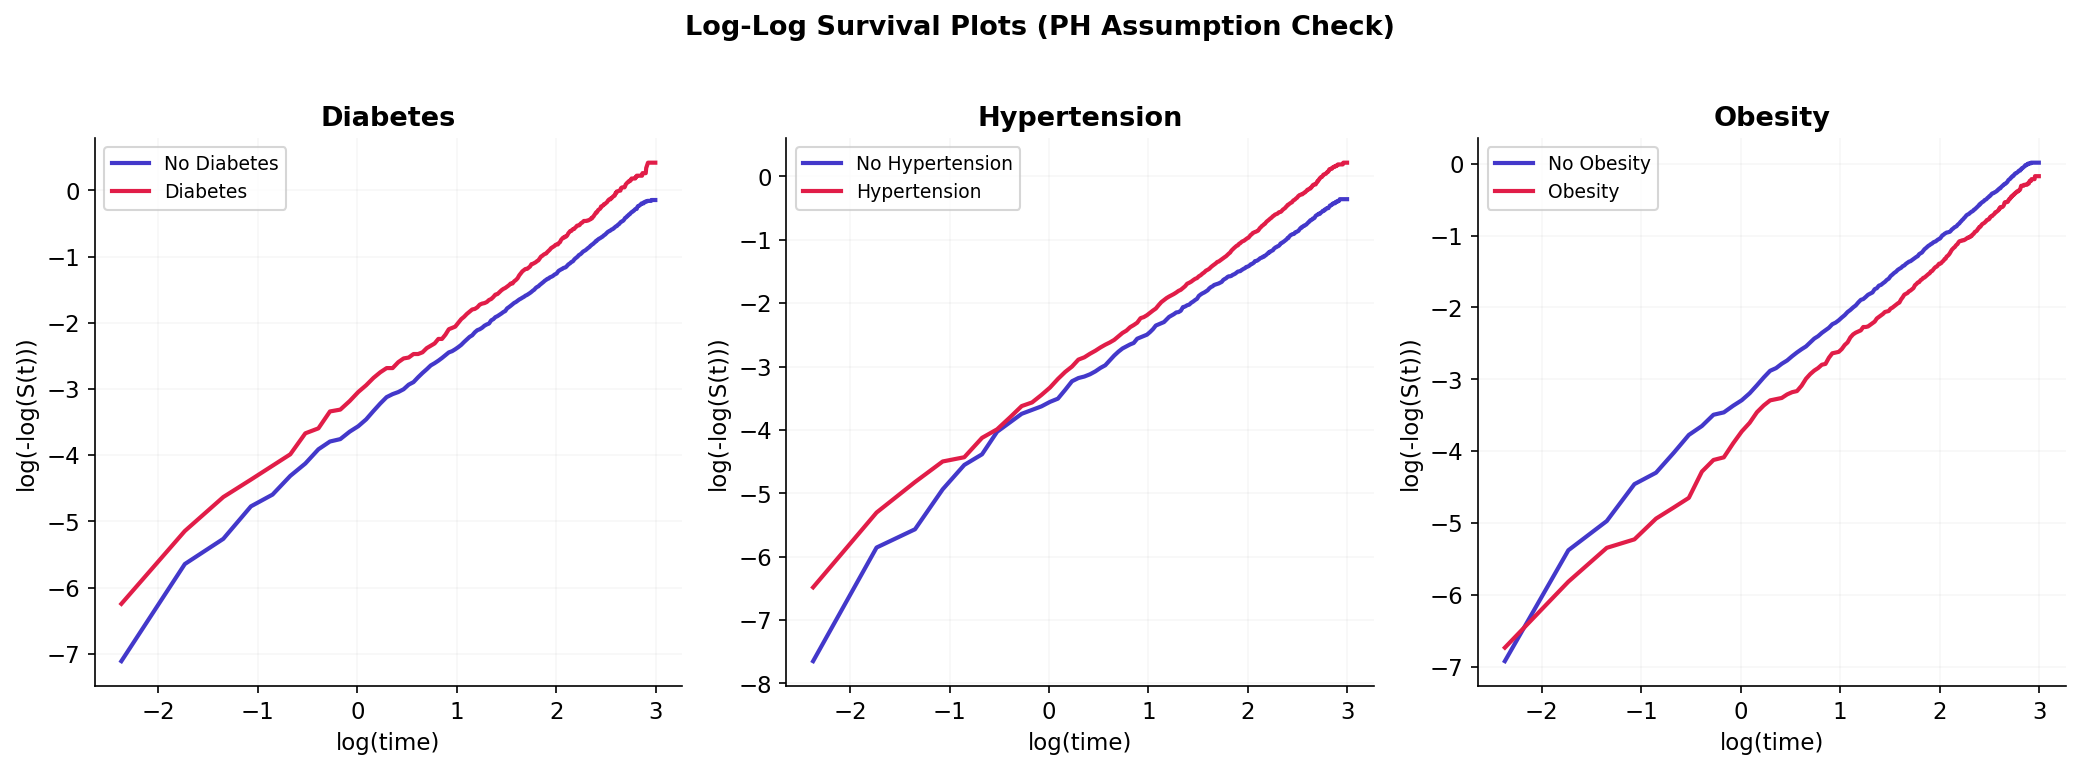

Saved: figures/loglog_plots.png

Interpretation: Parallel curves = PH holds. Crossing/diverging = PH violated.


In [4]:
# ============================================================
# STEP 7.4 — Log-log survival plots for key exposures
# ============================================================
# If curves are parallel, PH holds.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, (var, title) in enumerate([('diabetes', 'Diabetes'), ('hypertension', 'Hypertension'), ('obese', 'Obesity')]):
    ax = axes[idx]
    for val, label, color in [(0, f'No {title}', COLORS[0]), (1, title, COLORS[1])]:
        grp = cs_complete[cs_complete[var] == val]
        kmf = KaplanMeierFitter()
        kmf.fit(grp['T'], event_observed=grp['E'], label=label)
        
        # Log-log transform: plot log(-log(S(t))) vs log(t)
        st = kmf.survival_function_
        st = st[st.iloc[:, 0] > 0.01]  # avoid log(0)
        log_t = np.log(st.index + 0.01)
        log_neg_log_s = np.log(-np.log(st.iloc[:, 0]))
        
        ax.plot(log_t, log_neg_log_s, color=color, linewidth=2, label=label)
    
    ax.set_xlabel('log(time)')
    ax.set_ylabel('log(-log(S(t)))')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.1)

plt.suptitle('Log-Log Survival Plots (PH Assumption Check)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'loglog_plots.png', bbox_inches='tight')
plt.show()
print('Saved: figures/loglog_plots.png')
print('\nInterpretation: Parallel curves = PH holds. Crossing/diverging = PH violated.')

In [5]:
# ============================================================
# STEP 7.5 — Summary of PH diagnostics
# ============================================================

print('=== PH ASSUMPTION DIAGNOSTIC SUMMARY ===')
print()
print('Formal test (Schoenfeld residual correlation with time):')
for var in covariates:
    row = ph_test.summary.loc[var]
    p = row['p']
    status = 'VIOLATED (p<0.05)' if p < 0.05 else 'Satisfied'
    print(f'  {var:<25} {status}')
print()
print('Visual assessment:')
print('  Schoenfeld plots: check if LOWESS lines are approximately flat')
print('  Log-log plots: check if curves are approximately parallel')
print()
if violations:
    print(f'Variables with potential PH violations: {violations}')
    print()
    print('Clinical interpretation:')
    print('  With large N (~4,700), formal tests are overpowered and may flag')
    print('  minor, clinically irrelevant departures from PH.')
    print('  Visual assessment of Schoenfeld and log-log plots is more informative.')
    print('  If the LOWESS line is reasonably flat and log-log curves are roughly')
    print('  parallel, the violation is negligible for practical purposes.')
    print()
    print('  Approach: Report the violation in the paper as a limitation.')
    print('  Sensitivity analysis: fit restricted mean survival time (RMST)')
    print('  or time-stratified models in Step 9.')
else:
    print('All variables satisfy PH. No additional modeling needed.')

=== PH ASSUMPTION DIAGNOSTIC SUMMARY ===

Formal test (Schoenfeld residual correlation with time):
  diabetes                  Satisfied
  hypertension              Satisfied
  obese                     VIOLATED (p<0.05)
  age                       VIOLATED (p<0.05)
  female                    Satisfied
  race_black                Satisfied
  race_mexican              Satisfied
  race_hispanic             Satisfied
  race_other                Satisfied
  smoke_former              Satisfied
  smoke_current             Satisfied

Visual assessment:
  Schoenfeld plots: check if LOWESS lines are approximately flat
  Log-log plots: check if curves are approximately parallel

Variables with potential PH violations: ['obese', 'age']

Clinical interpretation:
  With large N (~4,700), formal tests are overpowered and may flag
  minor, clinically irrelevant departures from PH.
  Visual assessment of Schoenfeld and log-log plots is more informative.
  If the LOWESS line is reasonably flat and log

---
## Step 7 Summary

### Tests Performed
1. Formal Schoenfeld residual test (rank-based time transform)
2. Schoenfeld residual scatter plots with LOWESS smoothing
3. Log-log survival plots for 3 key exposures

### Figures
- `schoenfeld_residuals.png` - Residual plots for diabetes, hypertension, obesity, age
- `loglog_plots.png` - Log-log survival plots for 3 exposures

### Interpretation
- With N > 4,700, formal tests are very sensitive to minor deviations
- Visual assessment is the standard approach in epidemiology
- Any violations noted as limitations in the manuscript

### Next Step
**Step 8:** Forest plot (publication figure) and sensitivity analyses